# Driving School Data Analysis


## Introduction

The objective of this project is to answer **"What factors are associated with driving-test outcomes among driving-school pupils?"**. The data used in this study was collected from a single driving school, therefore the findings and conclusions drawn from the analysis will be specific to this school and may not be generalisable to other driving schools.

## Describing the Data

### Data Dictionary

| Column name   | Description   |
| ------------- | ------------- |
| Pupil Ref     | Identifies the pupil |
| Locale        | Area associated with the pupil |
| Source        | How the pupil first came into contact with the school |
| Status        | Indicates whether the pupil is still enrolled with the driving school |
| Theory        | Passed/Failed/NaN |
| Practical     | Passed/Failed/NaN |
| Amount Paid   | Amount of money received from the pupil |
| Hours Paid    | Number of hours Paid |
| Lessons Recieved | Number of lessons the pupil has recieved |
| Hours Recieved | Number of hours the pupil has recieved |
| Balance Hours Due | Number of hours paid for but not yet received |
| Outcome        | Practical Passed |
| Attempt Number | Number of times pupil sat test |
| Number of Driver Errors | Errors obtained for the corresponding outcome |
| CF Car/PRN | Driving school car or other |


In [113]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [114]:
#Loading the datasets
Pupil_directory = pd.read_csv("Pupil_Directory.csv", index_col = 0)
Pupil_stats = pd.read_csv("Pupil_Stats.csv", index_col = 0)

Pupil_directory.head()

,Locale,Source,Status,Theory,Practical,Amount Paid,Hours Paid,Lessons Received,Hours Received,Balance Hours Due
Pupil Ref,,,,,,,,,,
1,Clerwood,MDS,Archive,Pass,Pass,440.0,14.5,10,14.5,0.0
2,Balerno,Referral,Archive,Pass,Pass,710.0,23.5,16,23.5,0.0
3,Balerno,MDS,Archive,Pass,Pass,1110.0,40.0,26,40.0,0.0
4,Currie,MDS,Archive,Pass,Pass,550.0,18.5,12,18.0,0.0
5,Morningside,Referral,Archive,Pass,Pass,650.0,12.0,8,12.0,0.0


In [115]:
Pupil_stats.head()

,Outcome,Attempt Number,Number of Driver Errors (Passes only),CF Car/PRN?
Pupil Ref,,,,
1,Pass,1,3,Y
2,Pass,1,4,Y
3,Fail,1,NaN,Y
4,Pass,1,6,Y
5,Pass,1,0,N


## Data Cleaning

In [117]:
#Checking the shape of each dateset
print(Pupil_directory.shape)
print(Pupil_stats.shape)

(186, 10)
(184, 4)


In [118]:
#Checking the data types of each column
Pupil_directory.dtypes

Locale                object
Source                object
Status                object
Theory                object
Practical             object
Amount Paid          float64
Hours Paid           float64
Lessons Received       int64
Hours Received       float64
Balance Hours Due    float64
dtype: object

In [119]:
Pupil_stats.dtypes

Outcome                                  object
Attempt Number                            int64
Number of Driver Errors (Passes only)    object
CF Car/PRN?                              object
dtype: object

In [120]:
#Changing column names to be easily indexable
Pupil_directory = Pupil_directory.rename(columns = {"Pupil Ref" : "Pupil_Ref", "Amount Paid" : "Amount_Paid", "Lessons Received" : "Lessons_Received", "Hours Paid" : "Hours_Paid", "Hours Received" : "Hours_Received", "Balance Hours Due" : "Balance_Hours_Due"}, inplace = False)
Pupil_stats = Pupil_stats.rename(columns = {"Pupil Ref" : "Pupil_Ref", "Attempt Number" : "Attempt_Number", "Number of Driver Errors (Passes only)" : "Num_errors", "CF Car/PRN?" : "CF_Car"}, inplace = False)

In [121]:
#Checking 'NaN' (null values) values in the dataset
Pupil_directory.isnull().sum()

Locale                0
Source                0
Status                0
Theory               19
Practical            37
Amount_Paid           0
Hours_Paid            0
Lessons_Received      0
Hours_Received        0
Balance_Hours_Due     0
dtype: int64

Therefore, 19 pupils have not yet sat their theory test, and 37 pupils have not yet sat their practical test.

In [123]:
Pupil_stats.isnull().sum()

Outcome            0
Attempt_Number     0
Num_errors        57
CF_Car             0
dtype: int64

The Num_errors variable is only recorded for pupils who passed their practical test. Therefore, missing values in this variable correspond to failed tests rather than zero driver errors.

In [125]:
Pupil_directory.describe()

,Amount_Paid,Hours_Paid,Lessons_Received,Hours_Received,Balance_Hours_Due
count,186.000000,186.000000,186.000000,186.000000,186.000000
mean,1141.387204,30.827957,20.629032,31.263441,0.244624
std,606.786674,15.767653,10.497208,14.362130,1.388407
min,0.000000,0.000000,0.000000,0.000000,-1.500000
25%,782.500000,22.625000,15.000000,23.000000,0.000000
50%,1100.000000,30.500000,20.000000,30.750000,0.000000
75%,1460.000000,38.875000,25.000000,39.000000,0.000000
max,3840.000000,105.000000,96.000000,105.000000,10.500000


In [126]:
Pupil_stats.describe()

,Attempt_Number
count,184.000000
mean,1.228261
std,0.503610
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,4.000000


#### Grouping Pupil_directory in terms of Pupils passing either theory or practical

In [128]:
Pupil_Pass = Pupil_directory[(Pupil_directory['Theory'] == 'Pass') | (Pupil_directory['Practical'] == 'Pass')]
Pupil_Fail = Pupil_directory[(Pupil_directory['Theory'] == 'Fail') | (Pupil_directory['Practical'] == 'Fail')]


#### Pass rate

In [130]:
Pupil_Practical_Pass = Pupil_stats[(Pupil_stats['Outcome'] == 'Pass')]
Pass_rate = len(Pupil_Practical_Pass['Outcome'])/len(Pupil_stats)
Pass_rate


0.7010869565217391

The driving school has an overall practical driving test pass rate of 70.1%, meaning that 70.1% of all practical driving test attempts resulted in a pass.

## Exploratory Data Analysis
In the exploratory data analysis, I will be looking at the distribution of the data to get a better understanding of the data. After that, I will be looking at the relationship between the dependent variable and the independent variables.

#### Practical Test Attempts Distribution

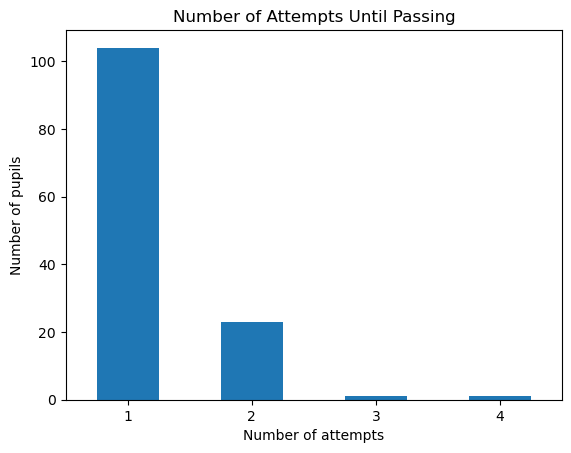

In [134]:
#subsetting Pupil_stats to just have outcomes containing passess
Pass_attemps = Pupil_stats[Pupil_stats['Outcome'] == 'Pass']


#Plotting
Pass_attemps['Attempt_Number'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Number of attempts')
plt.ylabel('Number of pupils')
plt.title('Number of Attempts Until Passing')
plt.xticks(rotation=0)
plt.show()



In [135]:
#Percentage of people passing for each attempt
Attempt_one = (len(Pass_attemps[Pass_attemps.Attempt_Number == 1])/len(Pass_attemps))*100
Attempt_two = (len(Pass_attemps[Pass_attemps.Attempt_Number == 2])/len(Pass_attemps))*100
Attempt_three = (len(Pass_attemps[Pass_attemps.Attempt_Number == 3])/len(Pass_attemps))*100
Attempt_four = (len(Pass_attemps[Pass_attemps.Attempt_Number == 4])/len(Pass_attemps))*100

The results indicate that, among pupils who passed their practical driving test, 80.62% passed on their first attempt, while 17.83% passed on their second attempt. A further 0.77% passed on their third or fourth attempt.

#### Number of Driver Errors Distribution

Text(0.5, 1.0, 'Number of Driver Errors Distribution')

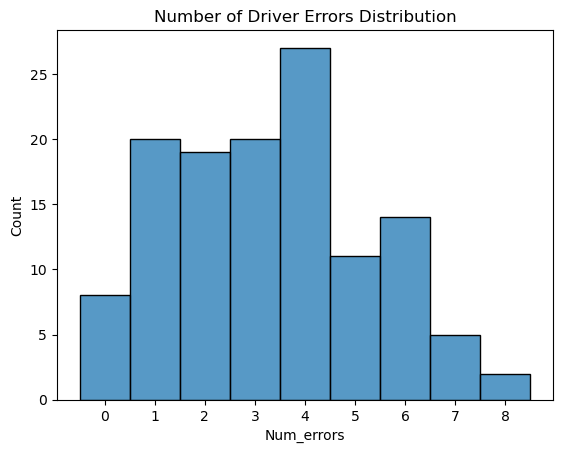

In [138]:
Pass_attemps = Pass_attemps.sort_values(by='Num_errors', ascending=True)
sns.histplot(Pass_attemps['Num_errors']).set_title('Number of Driver Errors Distribution')

In the dataset, the number of driver errors is highest at 4 errors. Most drivers have between 1 and 6 errors, while very few drivers have more than 7 errors.

#### Hours Recieved Distribution

Text(0.5, 1.0, 'Distribution of hours received across all pupils.')

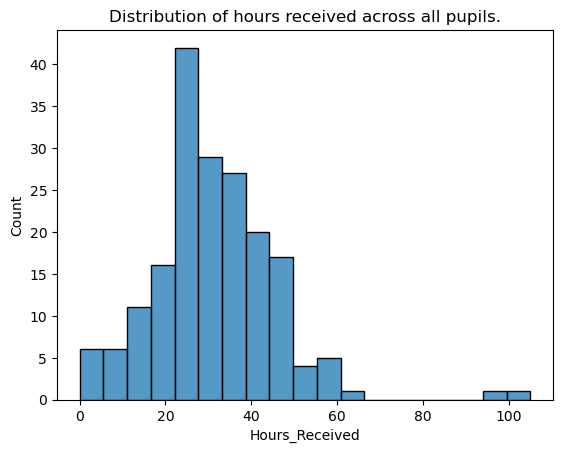

In [141]:
Pupil_directory = Pupil_directory.sort_values(by='Hours_Received', ascending=True)
sns.histplot(Pupil_directory['Hours_Received']).set_title('Distribution of hours received across all pupils.')

The majority of pupils have recieved between 20 and 40 hours of lessons. There are some high-value observations around the 100-hour mark.

#####  Number of hours recieved for Passed vs Failed

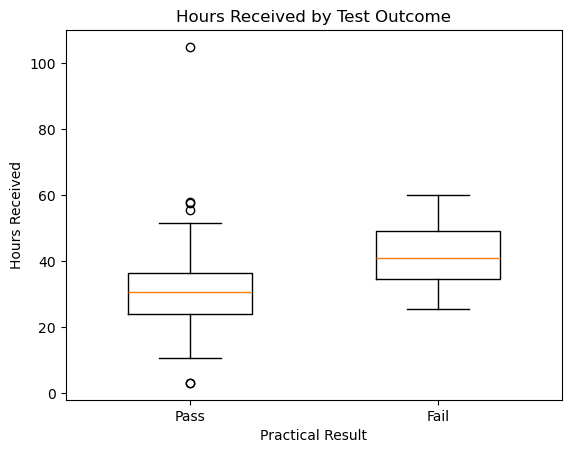

In [144]:
Pupil_Pass_Practical = Pupil_directory[Pupil_directory['Practical'] == 'Pass']
Pupil_Pass_Practical = Pupil_Pass_Practical.Hours_Received
Pupil_Fail_Practical = Pupil_directory[Pupil_directory['Practical'] == 'Fail']
Pupil_Fail_Practical = Pupil_Fail_Practical.Hours_Received

plt.boxplot([Pupil_Pass_Practical,Pupil_Fail_Practical], tick_labels = ['Pass' , 'Fail'], widths = 0.5)
plt.xlabel('Practical Result')
plt.ylabel('Hours Received')
plt.title('Hours Received by Test Outcome')

plt.show()

The Pass group has a lower median number of hours received compared with the Fail group. At first this may appear counterintuitive, as we might expect pupils who pass to have received more training. However, this association does not imply that receiving more hours causes pupils to fail. One possible explanation is that pupils who require additional support may take more lessons before attempting or retaking their test. 

The Pass group also contains several outliers. These observations should not automatically be removed, as they may represent genuine differences in the amount of training required by individual pupils. Possible explanations include previous driving experience or individual differences in learning requirements, although these explanations cannot be established from the available data alone.

##### To further investigate the question, "Why does the Fail group have a higher median number of hours?", we will examine the relationship between hours received and the number of test attempts, followed by the relationship between hours received and test outcome.

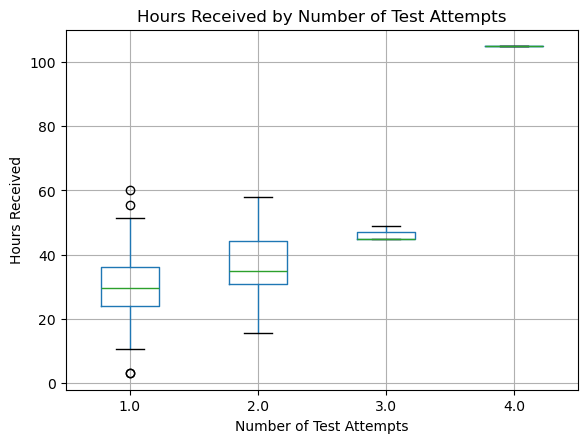

In [147]:
max_attempts = Pupil_stats.groupby(Pupil_stats.index)["Attempt_Number"].max()
hours = Pupil_directory["Hours_Received"]
Attempt_hours = pd.DataFrame({"Attempts": max_attempts, "Hours": hours})
Attempt_hours = Attempt_hours.dropna()
Attempt_hours
Attempt_hours.boxplot(column="Hours",by="Attempts")

plt.xlabel("Number of Test Attempts")
plt.ylabel("Hours Received")
plt.title("Hours Received by Number of Test Attempts")
plt.suptitle("")
plt.show()

There appears to be a positive relationship between between the number of test attempts and hours received:
1 attempt: median ≈ 30 hours,
2 attempts: median ≈ 35 hours.
3 attempts: median ≈ 45 hours,
4 attempts: ≈ 105 hours (but this appears to be only one pupil).

The median hours received increases from approximately 30 hours for pupils with one attempt to approximately 35 hours for two attempts and 45 hours for three attempts. This suggests that pupils who have made more test attempts tend to have received more driving lessons. However, the four-attempt group contains only one observation and therefore cannot provide a reliable representation of pupils with four attempts.

This finding may help explain why the Fail group has a higher median number of hours received. Pupils who fail may subsequently receive additional lessons before making another attempt. However, because the dataset records total hours received rather than hours received before each individual test, we cannot establish the direction of causality from this analysis.

In [149]:
r, p = pearsonr(Attempt_hours["Attempts"],Attempt_hours["Hours"])

print("Correlation:", r)
print("P-value:", p)

Correlation: 0.4589019111660007
P-value: 4.466498917009318e-09


A Pearson correlation test found a moderate positive correlation between hours received and the number of practical test attempts r = 0.459, p < 0.001. This provides strong statistical evidence of a positive linear association between the two variables. Therefore, pupils with more test attempts tend to have received more hours of instruction. However, this result does not establish causation.

#### hours received between pupils who passed and pupils who failed

In [152]:
final_outcome = Pupil_stats.groupby(Pupil_stats.index)["Outcome"].last()
Outcome_hours = pd.DataFrame({"Outcome": final_outcome, "Hours": Pupil_directory["Hours_Received"]})

print(Outcome_hours.head())

          Outcome  Hours
Pupil Ref               
1            Pass   14.5
2            Pass   23.5
3            Pass   40.0
4            Pass   18.0
5            Pass   12.0


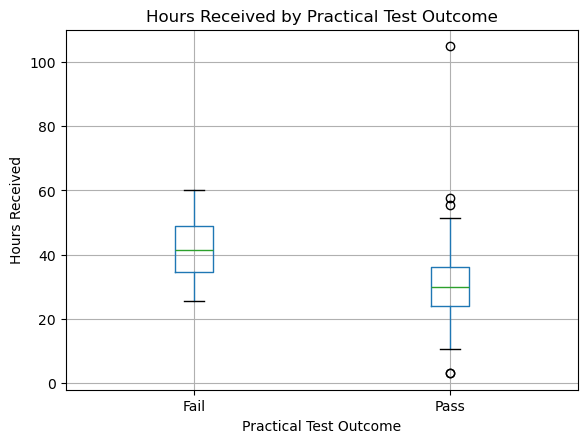

In [153]:
Outcome_hours.boxplot(column="Hours", by="Outcome")

plt.xlabel("Practical Test Outcome")
plt.ylabel("Hours Received")
plt.title("Hours Received by Practical Test Outcome")
plt.suptitle("")

plt.show()

In [154]:
print(Outcome_hours.groupby("Outcome")["Hours"].median())

Outcome
Fail    41.5
Pass    30.0
Name: Hours, dtype: float64


The median number of hours received was higher for pupils who failed their practical test (41.5 hours) compared with those who passed (30 hours). This indicates that pupils who ultimately failed tended to have received more driving instruction than pupils who passed.

However, this does not mean that receiving more lessons makes a pupil more likely to fail. Pupils who struggle with learning to drive may require more instruction, and pupils who fail may also receive additional lessons before attempting the test again. As the dataset records total hours received rather than hours received before each individual test, the direction of this relationship cannot be established.

In [157]:
from scipy.stats import mannwhitneyu

passed = Outcome_hours[Outcome_hours["Outcome"] == "Pass"]["Hours"]
failed = Outcome_hours[Outcome_hours["Outcome"] == "Fail"]["Hours"]

stat, p = mannwhitneyu(passed, failed)

print("U statistic:", stat)
print("P-value:", p)

U statistic: 505.0
P-value: 1.390053220204393e-05


A Mann–Whitney U test found a statistically significant difference in hours received between pupils who ultimately passed and failed their practical test (U = 505, p < 0.001). The median number of hours received was 30 hours for pupils who passed and 41.5 hours for pupils who failed. This suggests that pupils who failed tended to have received more hours of instruction.

#### Practical Test Outcome and CF Car/PRN

In [160]:
car_outcome = pd.crosstab(Pupil_stats["CF_Car"],Pupil_stats["Outcome"])
print(car_outcome)

Outcome  Fail  Pass
CF_Car             
N           9    33
Y          46    96


In [161]:
car_pass_rate = pd.crosstab(Pupil_stats["CF_Car"],Pupil_stats["Outcome"],normalize="index") * 100
print(car_pass_rate)

Outcome       Fail       Pass
CF_Car                       
N        21.428571  78.571429
Y        32.394366  67.605634


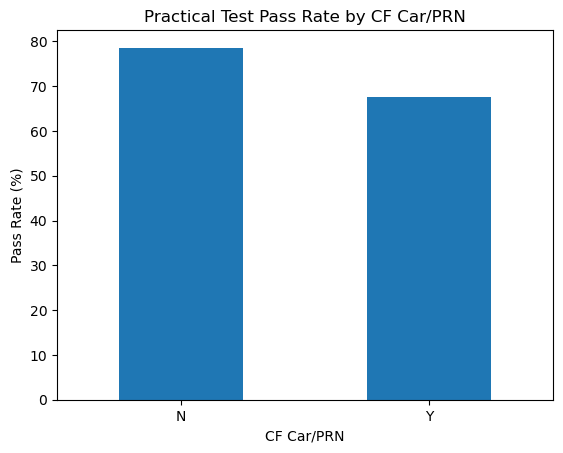

In [162]:
car_pass_rate["Pass"].plot(kind="bar")
plt.title("Practical Test Pass Rate by CF Car/PRN")
plt.xlabel("CF Car/PRN")
plt.ylabel("Pass Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [163]:
from scipy.stats import chi2_contingency

table = pd.crosstab(Pupil_stats["CF_Car"],Pupil_stats["Outcome"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-squared statistic:", chi2)
print("P-value:", p)

Chi-squared statistic: 1.3734106778325574
P-value: 0.24122674539397015


Since the p-value is greater than 0.05, there is insufficient statistical evidence to conclude that CF Car/PRN and practical test outcome are associated in this dataset. Therefore, the difference in observed pass rates may be due to random variation rather than a systematic relationship between the variables.

## Machine Learning

In [166]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Pupil_data = Pupil_stats.join(Pupil_directory[["Locale", "Source"]], how="left")


# Sort test attempts by attempt number
Pupil_data_sorted = Pupil_data.sort_values("Attempt_Number")

# Keep the final test attempt for each pupil
final_outcome = Pupil_data_sorted.groupby(Pupil_data_sorted.index).last()

ml_data = final_outcome[["Outcome", "CF_Car", "Locale", "Source"]].copy()

# Pass = 1
# Fail = 0
y = ml_data["Outcome"].replace({"Pass": 1,"Fail": 0})

X = ml_data[["CF_Car", "Locale", "Source"]].copy()

X["CF_Car"] = X["CF_Car"].replace({"Y": 1,"N": 0})

X = pd.get_dummies(X,columns=["Locale", "Source"],dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

model = DecisionTreeClassifier(max_depth=3,random_state=1)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report( y_test,predictions,target_names=["Fail", "Pass"],zero_division=0))

Accuracy: 0.8666666666666667

Confusion Matrix:
[[ 0  4]
 [ 0 26]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         4
        Pass       0.87      1.00      0.93        26

    accuracy                           0.87        30
   macro avg       0.43      0.50      0.46        30
weighted avg       0.75      0.87      0.80        30



C:\Users\oscar\AppData\Local\Temp\ipykernel_26312\1630045736.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = ml_data["Outcome"].replace({"Pass": 1,"Fail": 0})
C:\Users\oscar\AppData\Local\Temp\ipykernel_26312\1630045736.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["CF_Car"] = X["CF_Car"].replace({"Y": 1,"N": 0})


A decision tree classifier was trained to predict practical test outcomes using the available features. The model achieved an accuracy of 86.7% on the test set. However, the confusion matrix shows that the model correctly identified 26 of the 26 pupils who passed, but none of the 4 pupils who failed. This suggests that the model was substantially better at identifying passes than failures. The relatively small dataset and imbalance between the two outcome classes should therefore be considered when interpreting the model's performance.

## Conclusion

This project investigated the factors associated with practical driving-test outcomes among pupils at a single driving school. The analysis found that pupils who eventually passed their practical test most commonly did so on their first attempt, with fewer pupils passing on subsequent attempts.

A positive relationship was found between the number of practical test attempts and the total number of hours received. Pupils with more attempts tended to have received more hours of instruction. There was also a statistically significant difference in total hours received between pupils who ultimately passed and failed their practical test, with failed pupils having a higher median number of hours. However, these findings do not imply that receiving more driving lessons causes pupils to fail. Since hours received may include lessons taken after a failed test, the direction of the relationship cannot be established from the available data.

The analysis also investigated the relationship between practical test outcome and CF Car/PRN. The pass rate was 78.57% for CF_Car = N and 67.61% for CF_Car = Y. However, a chi-squared test found no statistically significant association between CF Car/PRN and practical test outcome (χ² = 1.373, p = 0.241). Therefore, there was insufficient statistical evidence to conclude that the type of car used was associated with practical test outcome in this dataset.

The machine-learning analysis used a decision tree classifier to investigate whether the available pupil characteristics could be used to predict practical test outcomes. The model achieved an accuracy of 86.7% on the test set. However, it correctly identified all 26 pupils who passed but none of the 4 pupils who failed. This indicates that the model was substantially better at identifying passes than failures. The relatively small dataset and imbalance between the two outcome classes should therefore be considered when interpreting the model's performance.

Overall, the analysis provides evidence of associations between driving instruction, test attempts and practical test outcomes within this driving school, while no statistically significant association was found between CF Car/PRN and test outcome. However, the dataset is relatively small and comes from a single driving school, meaning the findings may not generalise to other driving schools. Further data, particularly from multiple driving schools and with information recorded before each individual test, would be needed to investigate these relationships and develop a more reliable predictive model.